# Hybrid RAG Implementation
This notebook combines Self-RAG, Corrective-RAG (CRAG), and Multi-hop RAG for a robust question-answering system.

In [20]:
# Install required packages (run in terminal or uncomment if needed)
# !pip install langchain langchain-community langchain-openai langgraph chromadb google-cloud-bigquery pandas python-dotenv

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.utilities import SQLDatabase
from google.cloud import bigquery
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.documents import Document
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field
from typing import List
from typing_extensions import TypedDict
import langgraph.graph as lg
import os
from tavily import TavilyClient
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Set up Google BigQuery (ensure GOOGLE_APPLICATION_CREDENTIALS is set in .env)

client = bigquery.Client()
project_id = client.project  

# ✅ Connect SQLDatabase to BigQuery
db = SQLDatabase.from_uri(f"bigquery://{project_id}")

# Initialize LLMs
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_fast = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# Define Graph State
class GraphState(TypedDict):
    question: str
    generation: str
    documents: List[str]
    subquestions: List[str]
    iteration: int

# Initial RAG corpus
docs = [
    'The product "Collections Etc - Tanya Circles V-Neck Dress" had the highest number of sales in January 2024, with a total of 2 sales.',
    'The top country for sales in January 2024 was the United States, with a total of 2 sales.',
    'In January 2024, the total sales for the product "Collections Etc - Tanya Circles V-Neck Dress" was $27.94.',
    'Customers who purchased the "Tanya Circles V-Neck Dress" also bought items such as leggings, jackets, and Bermuda shorts.',
    'The average discount applied to women’s dresses in January 2024 was 15%.',
    'January 2024 saw a promotional campaign focused on winter apparel, including dresses and sweaters.',
    'Social media engagement for the "Tanya Circles V-Neck Dress" peaked during the second week of January.',
    'Compared to January 2023, sales for the "Tanya Circles V-Neck Dress" increased by 20%.',
    'The product received an average customer rating of 4.8 stars out of 5 based on 9 reviews.',
    'Inventory levels for the "Tanya Circles V-Neck Dress" were higher than average, with sufficient stock in most regions.'
]

# Create vector store
documents = [Document(page_content=text) for text in docs]
text_splitter = RecursiveCharacterTextSplitter(chunk_size=250, chunk_overlap=0)
doc_splits = text_splitter.split_documents(documents)
vectorstore = Chroma.from_documents(documents=doc_splits, embedding=OpenAIEmbeddings())
retriever = vectorstore.as_retriever()

print("✅ Vectorstore initialized.")

/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/google/cloud/bigquery/client.py:595: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(
/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/sqlalchemy_bigquery/_types.py:101: SAWarning: Did not recognize type 'GEOGRAPHY' of column 'distribution_center_geom'
  sqlalchemy.util.warn(
/Users/gretalerer/capstone_langgraph/venv/lib/python3.10/site-packages/sqlalchemy_bigquery/_types.py:101: SAWarning: Did not recognize type 'GEOGRAPHY' of column 'user_geom'
  sqlalchemy.util.warn(


✅ Vectorstore initialized.


In [22]:
# NL2SQL Functions
def write_query(question: str) -> str:
    prompt = f"""
    You are an AI that generates SQL queries for a BigQuery database.

    **Database dialect:** {db.dialect}
    **Schema:** {db.get_table_info()}
    
    **User question:** "{question}"
    
    **Rules:**
    - You should write a query that answers the user question.
    - **Return only the SQL query.** No explanations.
    - The SQL query must be valid BigQuery SQL.
    - **Do not assume unknown columns.**
    
    Example Format:
    SELECT column FROM table WHERE condition;
    """
    raw_result = llm.invoke(prompt)

    sql_query = raw_result.content.strip().replace("```sql", "").replace("```", "").strip()

def execute_query(sql_query: str) -> str:
    try:
        query_job = client.query(sql_query)
        results_df = query_job.result().to_dataframe()
        results_markdown = results_df.to_markdown()
        return results_markdown
    except Exception as e:
        return f"❌ Error: {str(e)}"

def summarize_result(sql_query: str, results: str) -> str:
    if "❌ Error" in results:
        return "I couldn't process the query due to an error."

    prompt = f"""
    You are a data analyst. Based on the following SQL query and its output, write a straightforward natural language answer that directly communicates the query result.

    **SQL Query:** 
    ```sql
    {sql_query}
    ```

    **Results:**
    {results}

    **Rules:**
    - Write in a conversational style.
    - Do not give an opinion or interpretation.

    Example:
    China was the country with the highest number of orders, with a total of 42,355 orders.
    """
    response = llm_fast.invoke(prompt)
    return response.content.strip()
    

In [23]:
# Question Rewriter (Multi-hop RAG)
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Rewrite the user question to optimize it for retrieval, focusing on causal factors and broader context."),
    ("human", "Original question: {question}\nRewritten query:")
])
question_rewriter = rewrite_prompt | llm | StrOutputParser()

# Retrieval Grader (CRAG)
class GradeDocuments(BaseModel):
    binary_score: str = Field(description="'yes' if relevant, 'no' if not")
structured_llm_grader = llm.with_structured_output(GradeDocuments)
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", "Assess if the document supports a causal explanation for the question. Mark 'yes' if it provides context or factors, 'no' if irrelevant."),
    ("human", "Document: {document}\nQuestion: {question}")
])
retrieval_grader = grade_prompt | structured_llm_grader

# Generation (Self-RAG)
causal_prompt = ChatPromptTemplate.from_messages([
    ("system", "Generate a causal insight based strictly on the context. Avoid speculation."),
    ("human", "Question: {question}\nContext: {context}\nCausal Insight:")
])
rag_chain = causal_prompt | llm | StrOutputParser()

# Hallucination Grader (Self-RAG)
class GradeHallucinations(BaseModel):
    binary_score: str = Field(description="'yes' if grounded, 'no' if hallucinated")
hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", "Check if the generation is grounded in the facts. Score 'yes' or 'no'."),
    ("human", "Facts: {documents}\nGeneration: {generation}")
])
hallucination_grader = hallucination_prompt | structured_llm_grader

# Answer Grader (Self-RAG)
class GradeAnswer(BaseModel):
    binary_score: str = Field(description="'yes' if addresses question, 'no' if not")
answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "Assess if the answer resolves the question. Score 'yes' or 'no'."),
    ("human", "Question: {question}\nGeneration: {generation}")
])
answer_grader = answer_prompt | structured_llm_grader

In [27]:
from tavily import TavilyClient


In [24]:
# Graph Nodes

load_dotenv()
tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def retrieve(state):
    print(f"\n[RETRIEVE] Starting for question: {state['question']}")
    rewritten_question = question_rewriter.invoke({"question": state["question"]})
    print(f"[RETRIEVE] Rewritten question: {rewritten_question}")
    docs = retriever.invoke(rewritten_question)
    graded_docs = []
    for doc in docs:
        score = retrieval_grader.invoke({"document": doc.page_content, "question": state["question"]}).binary_score
        print(f"[RETRIEVE] Document: {doc.page_content[:50]}... | Relevant? {score}")
        if score == "yes":
            graded_docs.append(doc.page_content)
    if not graded_docs:
        print("[RETRIEVE] No relevant docs from vectorstore, attempting SQL")
        sql_query = write_query(state["question"])
        print(f"[RETRIEVE] SQL Query: {sql_query}")
        results = execute_query(sql_query)
        print(f"[RETRIEVE] SQL Results: {results[:50]}...")
        summary = summarize_result(sql_query, results)
        if "error" not in summary.lower():
            graded_docs = [summary]
    print(f"[RETRIEVE] Retrieved {len(graded_docs)} documents")
    return {"documents": graded_docs, "question": state["question"], "iteration": state.get("iteration", 0)}

def web_search(state):
    if state["documents"] and all("error" in doc.lower() for doc in state["documents"]):
        print(f"\n[WEB_SEARCH] SQL failed, searching web for: {state['question']}")
        results = tavily.search(state["question"], max_results=3)["results"]
        web_docs = [f"{r['title']}: {r['content'][:200]}..." for r in results]
        print(f"[WEB_SEARCH] Found {len(web_docs)} web results")
        return {"documents": web_docs, "question": state["question"], "iteration": state["iteration"]}
    print(f"\n[WEB_SEARCH] Skipping, documents exist: {state['documents'][:50]}...")
    return state

def generate(state):
    print(f"\n[GENERATE] Generating for question: {state['question']}")
    context = "\n".join(state["documents"]) if state["documents"] else "No relevant data available."
    print(f"[GENERATE] Context: {context[:100]}...")
    generation = rag_chain.invoke({"context": context, "question": state["question"]})
    print(f"[GENERATE] Generated answer: {generation}")
    return {"generation": generation, "documents": state["documents"], "question": state["question"], "iteration": state["iteration"]}

def grade(state):
    print(f"\n[GRADE] Grading generation: {state['generation'][:50]}...")
    hallucination_score = hallucination_grader.invoke({"documents": state["documents"], "generation": state["generation"]}).binary_score
    answer_score = answer_grader.invoke({"question": state["question"], "generation": state["generation"]}).binary_score
    print(f"[GRADE] Hallucination score: {hallucination_score} | Answer score: {answer_score}")
    print(f"[GRADE] Iteration: {state['iteration'] + 1}")
    return {"generation": state["generation"], "documents": state["documents"], "question": state["question"], "iteration": state["iteration"] + 1, "hallucination": hallucination_score, "answer": answer_score}

def generate_subquestions(state):
    print(f"\n[SUBQUESTIONS] Generating subquestions for: {state['generation'][:50]}...")
    prompt = f"""
    Based on the generation '{state['generation']}', generate 2 follow-up questions for multi-hop reasoning using the SQL database or external sources.
    - Focus on causal factors or additional details.
    - Ensure they are answerable.
    """
    subquestions = llm_fast.invoke(prompt).content.split("\n")[:2]
    print(f"[SUBQUESTIONS] Subquestions: {subquestions}")
    return {"subquestions": subquestions, "generation": state["generation"], "documents": state["documents"], "question": state["question"], "iteration": state["iteration"]}

def multi_hop_retrieve(state):
    print(f"\n[MULTI-HOP] Retrieving for subquestions: {state['subquestions']}")
    sub_docs = []
    for subq in state["subquestions"]:
        sql_query = write_query(subq)
        print(f"[MULTI-HOP] Subquestion SQL: {sql_query}")
        results = execute_query(sql_query)
        print(f"[MULTI-HOP] Subquestion Result: {results[:50]}...")
        summary = summarize_result(sql_query, results)
        if "error" not in summary.lower():
            sub_docs.append(summary)
        else:
            print(f"[MULTI-HOP] SQL failed for {subq}, trying web search")
            web_results = tavily.search(subq, max_results=1)["results"]
            sub_docs.append(f"{web_results[0]['title']}: {web_results[0]['content'][:200]}..." if web_results else "No data found.")
    combined_docs = state["documents"] + sub_docs
    print(f"[MULTI-HOP] Total documents after multi-hop: {len(combined_docs)}")
    return {"documents": combined_docs, "question": state["question"], "generation": state["generation"], "iteration": state["iteration"]}

def decide_to_continue(state):
    print(f"\n[DECIDE] Hallucination: {state['hallucination']} | Answer: {state['answer']} | Iteration: {state['iteration']}")
    if state["hallucination"] == "no" or state["answer"] == "no":
        if state["iteration"] < 3:
            next_step = "multi_hop_retrieve" if state.get("subquestions") else "generate_subquestions"
            print(f"[DECIDE] Continuing to: {next_step}")
            return next_step
        print("[DECIDE] Max iterations reached, ending")
        return "end"
    print("[DECIDE] Scores are good, ending")
    return "end"

# Build Graph
workflow = lg.StateGraph(GraphState)
workflow.add_node("retrieve", retrieve)
workflow.add_node("web_search", web_search)
workflow.add_node("generate", generate)
workflow.add_node("grade", grade)
workflow.add_node("generate_subquestions", generate_subquestions)
workflow.add_node("multi_hop_retrieve", multi_hop_retrieve)
workflow.add_edge("retrieve", "web_search")
workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", "grade")
workflow.add_conditional_edges("grade", decide_to_continue, {"multi_hop_retrieve": "multi_hop_retrieve", "generate_subquestions": "generate_subquestions", "end": lg.END})
workflow.add_edge("generate_subquestions", "multi_hop_retrieve")
workflow.add_edge("multi_hop_retrieve", "generate")
workflow.set_entry_point("retrieve")
app = workflow.compile()

print("✅ Graph compiled with web search.")

✅ Graph compiled with web search.


In [28]:
# Run the Graph
initial_state = {"question": "Why was the top selling product in January 2024?", "iteration": 0}
result = app.invoke(initial_stated)
print("Final Answer:", result["generation"])
print("Documents Used:", result["documents"])


[RETRIEVE] Starting for question: Why was the top selling product in January 2024?
[RETRIEVE] Rewritten question: What factors contributed to the top-selling product's success in January 2024, considering market trends and consumer behavior?
[RETRIEVE] Document: The top country for sales in January 2024 was the ... | Relevant? no
[RETRIEVE] Document: The top country for sales in January 2024 was the ... | Relevant? no
[RETRIEVE] Document: The top country for sales in January 2024 was the ... | Relevant? no
[RETRIEVE] Document: The product "Collections Etc - Tanya Circles V-Nec... | Relevant? no
[RETRIEVE] No relevant docs from vectorstore, attempting SQL
[RETRIEVE] SQL Query: None
[RETRIEVE] SQL Results: ❌ Error: 400 POST https://bigquery.googleapis.com/...
[RETRIEVE] Retrieved 0 documents

[WEB_SEARCH] Skipping, documents exist: []...

[GENERATE] Generating for question: Why was the top selling product in January 2024?
[GENERATE] Context: No relevant data available....
[GENERATE] Gen

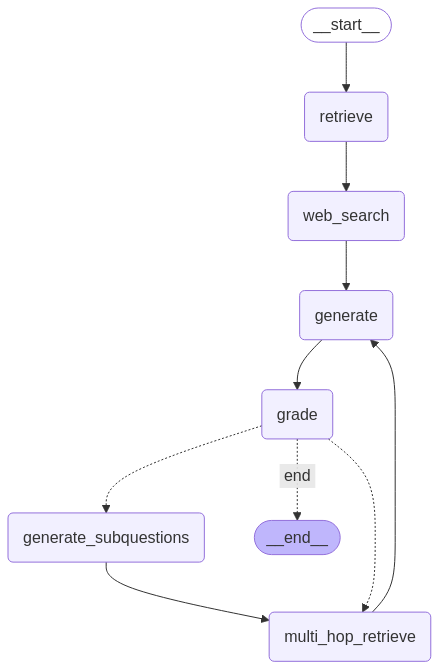

In [26]:
# Visualize Graph (Optional)
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))